# OTT 이탈 예측 모델
**원본 vs 전처리본 vs 피처추가본(v2) 3-way 비교**

타겟: repurchase (1=재결제, 0=이탈)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False
import warnings; warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline

try:
    import lightgbm as lgb; HAS_LGB = True
except ImportError:
    HAS_LGB = False; print("LightGBM 없음 - pip install lightgbm")
try:
    import xgboost as xgb; HAS_XGB = True
except ImportError:
    HAS_XGB = False; print("XGBoost 없음 - pip install xgboost")
print("라이브러리 로드 완료")

라이브러리 로드 완료


## 1. 데이터 로드

In [2]:
raw  = pd.read_csv("../data/Membership.csv",            encoding="utf-8-sig")
proc = pd.read_csv("../data/Membership_processing.csv", encoding="utf-8-sig")
v2   = pd.read_csv("../data/Membership_v2.csv",         encoding="utf-8-sig")
print(f"원본:       {raw.shape}")
print(f"전처리본:   {proc.shape}")
print(f"피처추가본: {v2.shape}")

원본:       (18183, 15)
전처리본:   (17774, 29)
피처추가본: (17774, 45)


## 2. 전처리 함수

In [3]:
def prepare_raw(df):
    d = df.copy()
    d["repurchase"] = (d["repurchase"] == "O").astype(int)
    for col in ["promotion_yn", "is_churn_prevented"]:
        d[col] = (d[col] == "O").astype(int)
    d["is_user_verified"] = (d["is_user_verified"] == "Y").astype(int)
    drop = ["user_no", "product_cd", "reg_date", "end_date"]
    d = d.drop(columns=[c for c in drop if c in d.columns])
    for col in d.select_dtypes(include="object").columns:
        d[col] = LabelEncoder().fit_transform(d[col].astype(str))
    return d.fillna(0)

def prepare_clean(df):
    d = df.copy()
    drop = ["user_no", "product_cd", "reg_date", "end_date"]
    d = d.drop(columns=[c for c in drop if c in d.columns])
    for col in d.select_dtypes(include="object").columns:
        if col != "repurchase":
            d[col] = LabelEncoder().fit_transform(d[col].astype(str))
    return d.fillna(0)

raw_ready  = prepare_raw(raw)
proc_ready = prepare_clean(proc)
v2_ready   = prepare_clean(v2)

X_raw,  y_raw  = raw_ready.drop(columns="repurchase"),  raw_ready["repurchase"]
X_proc, y_proc = proc_ready.drop(columns="repurchase"), proc_ready["repurchase"]
X_v2,   y_v2   = v2_ready.drop(columns="repurchase"),   v2_ready["repurchase"]

print(f"원본       피처: {X_raw.shape[1]}개")
print(f"전처리본   피처: {X_proc.shape[1]}개")
print(f"피처추가본 피처: {X_v2.shape[1]}개")

원본       피처: 10개
전처리본   피처: 24개
피처추가본 피처: 40개


In [4]:
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(X_raw,  y_raw,  test_size=0.2, random_state=42, stratify=y_raw)
Xp_tr, Xp_te, yp_tr, yp_te = train_test_split(X_proc, y_proc, test_size=0.2, random_state=42, stratify=y_proc)
Xv_tr, Xv_te, yv_tr, yv_te = train_test_split(X_v2,   y_v2,   test_size=0.2, random_state=42, stratify=y_v2)
print(f"원본       Train {Xr_tr.shape[0]} / Test {Xr_te.shape[0]}")
print(f"전처리본   Train {Xp_tr.shape[0]} / Test {Xp_te.shape[0]}")
print(f"피처추가본 Train {Xv_tr.shape[0]} / Test {Xv_te.shape[0]}")

원본       Train 14546 / Test 3637
전처리본   Train 14219 / Test 3555
피처추가본 Train 14219 / Test 3555


## 3. 모델 학습

In [5]:
def get_models():
    m = [
        ("Logistic Regression", Pipeline([("sc", StandardScaler()), ("lr", LogisticRegression(max_iter=1000, random_state=42))])),
        ("Random Forest",       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
        ("Gradient Boosting",   GradientBoostingClassifier(n_estimators=200, random_state=42)),
    ]
    if HAS_LGB: m.append(("LightGBM", lgb.LGBMClassifier(n_estimators=300, random_state=42, verbose=-1)))
    if HAS_XGB: m.append(("XGBoost",  xgb.XGBClassifier(n_estimators=300, random_state=42, eval_metric="logloss", verbosity=0)))
    return m

def run_models(label, models, X_tr, y_tr, X_te, y_te):
    print(f"\n{label}\n" + "-"*50)
    results = []
    for name, model in models:
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        y_prob = model.predict_proba(X_te)[:, 1]
        acc = accuracy_score(y_te, y_pred)
        auc = roc_auc_score(y_te, y_prob)
        f1  = f1_score(y_te, y_pred)
        print(f"  {name:<25}  Acc={acc:.4f}  AUC={auc:.4f}  F1={f1:.4f}")
        results.append({"name": name, "Accuracy": acc, "AUC": auc, "F1": f1, "model": model})
    return results

results_raw  = run_models("원본",       get_models(), Xr_tr, yr_tr, Xr_te, yr_te)
results_proc = run_models("전처리본",   get_models(), Xp_tr, yp_tr, Xp_te, yp_te)
results_v2   = run_models("피처추가본", get_models(), Xv_tr, yv_tr, Xv_te, yv_te)


원본
--------------------------------------------------
  Logistic Regression        Acc=0.6723  AUC=0.6225  F1=0.7957
  Random Forest              Acc=0.6338  AUC=0.6039  F1=0.7389
  Gradient Boosting          Acc=0.6857  AUC=0.6667  F1=0.7973
  LightGBM                   Acc=0.6764  AUC=0.6439  F1=0.7855
  XGBoost                    Acc=0.6654  AUC=0.6262  F1=0.7705

전처리본
--------------------------------------------------
  Logistic Regression        Acc=0.6906  AUC=0.6488  F1=0.8059
  Random Forest              Acc=0.6838  AUC=0.6420  F1=0.7905
  Gradient Boosting          Acc=0.6996  AUC=0.6693  F1=0.8066
  LightGBM                   Acc=0.6824  AUC=0.6481  F1=0.7895
  XGBoost                    Acc=0.6596  AUC=0.6136  F1=0.7669

피처추가본
--------------------------------------------------
  Logistic Regression        Acc=0.6937  AUC=0.6494  F1=0.8073
  Random Forest              Acc=0.6869  AUC=0.6484  F1=0.7974
  Gradient Boosting          Acc=0.6970  AUC=0.6691  F1=0.8054
  LightGBM 

## 4. 성능 비교표 & 시각화

In [6]:
def to_df(results):
    return pd.DataFrame([{k:v for k,v in r.items() if k!="model"} for r in results]).rename(columns={"name":"모델"}).set_index("모델")

df_r = to_df(results_raw)
df_p = to_df(results_proc)
df_v = to_df(results_v2)

compare = df_r[["AUC"]].rename(columns={"AUC":"AUC_원본"})
compare["AUC_전처리"]  = df_p["AUC"]
compare["AUC_v2"]      = df_v["AUC"]
compare["향상_전처리"] = compare["AUC_전처리"] - compare["AUC_원본"]
compare["향상_v2"]     = compare["AUC_v2"]     - compare["AUC_원본"]
display(compare.style.highlight_max(subset=["AUC_원본","AUC_전처리","AUC_v2"], color="#c6efce").format("{:.4f}"))

,AUC_원본,AUC_전처리,AUC_v2,향상_전처리,향상_v2
모델,,,,,
Logistic Regression,0.6225,0.6488,0.6494,0.0263,0.0269
Random Forest,0.6039,0.6420,0.6484,0.0381,0.0445
Gradient Boosting,0.6667,0.6693,0.6691,0.0025,0.0024
LightGBM,0.6439,0.6481,0.6455,0.0042,0.0016
XGBoost,0.6262,0.6136,0.6334,-0.0126,0.0073


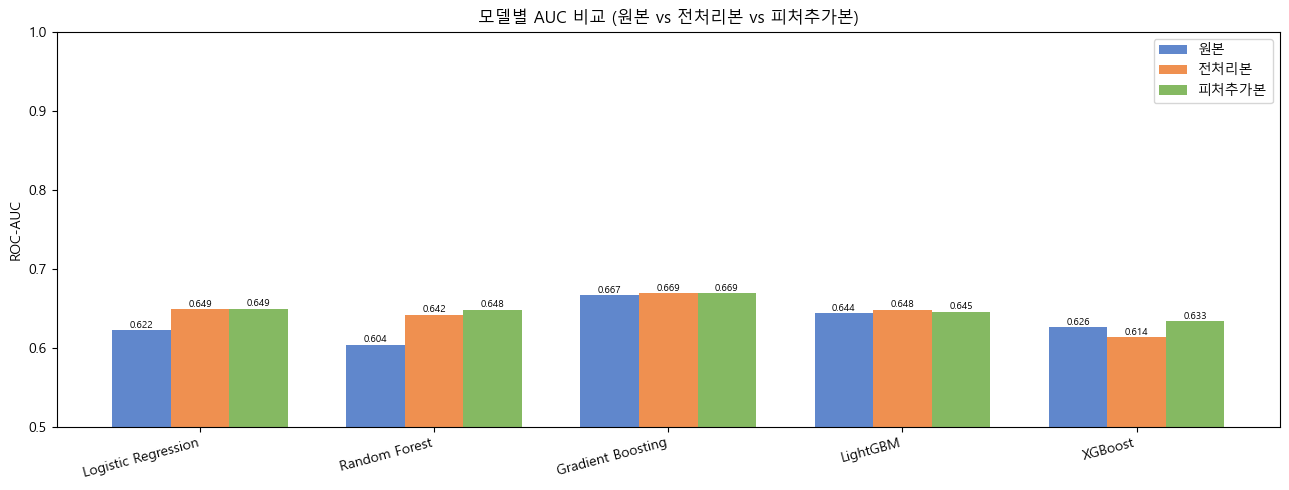

In [7]:
model_names = [r["name"] for r in results_raw]
auc_raw  = [r["AUC"] for r in results_raw]
auc_proc = [r["AUC"] for r in results_proc]
auc_v2   = [r["AUC"] for r in results_v2]
x = np.arange(len(model_names)); w = 0.25

fig, ax = plt.subplots(figsize=(13, 5))
b1 = ax.bar(x-w,   auc_raw,  w, label="원본",      color="#4472C4", alpha=0.85)
b2 = ax.bar(x,     auc_proc, w, label="전처리본",  color="#ED7D31", alpha=0.85)
b3 = ax.bar(x+w,   auc_v2,   w, label="피처추가본",color="#70AD47", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=15, ha="right")
ax.set_ylim(0.5, 1.0); ax.set_ylabel("ROC-AUC")
ax.set_title("모델별 AUC 비교 (원본 vs 전처리본 vs 피처추가본)"); ax.legend()
for bars, vals in [(b1,auc_raw),(b2,auc_proc),(b3,auc_v2)]:
    for b,v in zip(bars,vals):
        ax.text(b.get_x()+b.get_width()/2, v+0.003, f"{v:.3f}", ha="center", fontsize=7)
plt.tight_layout(); plt.show()

## 5. Confusion Matrix & 분류 리포트

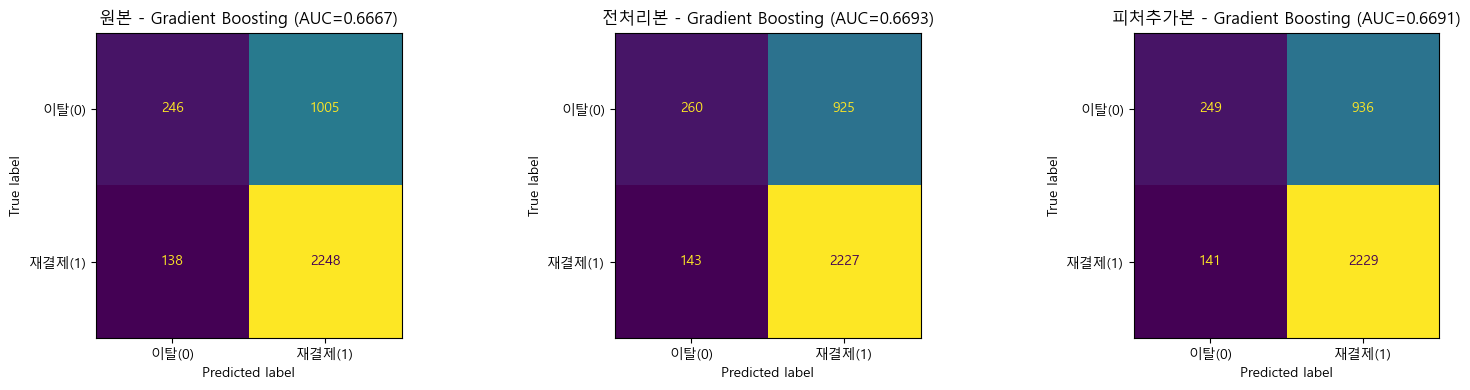

=== 원본 최고 모델: Gradient Boosting ===
              precision    recall  f1-score   support

          이탈       0.64      0.20      0.30      1251
         재결제       0.69      0.94      0.80      2386

    accuracy                           0.69      3637
   macro avg       0.67      0.57      0.55      3637
weighted avg       0.67      0.69      0.63      3637

=== 전처리본 최고 모델: Gradient Boosting ===
              precision    recall  f1-score   support

          이탈       0.65      0.22      0.33      1185
         재결제       0.71      0.94      0.81      2370

    accuracy                           0.70      3555
   macro avg       0.68      0.58      0.57      3555
weighted avg       0.69      0.70      0.65      3555

=== 피처추가본 최고 모델: Gradient Boosting ===
              precision    recall  f1-score   support

          이탈       0.64      0.21      0.32      1185
         재결제       0.70      0.94      0.81      2370

    accuracy                           0.70      3555
   macro avg   

In [8]:
best_raw  = max(results_raw,  key=lambda r: r["AUC"])
best_proc = max(results_proc, key=lambda r: r["AUC"])
best_v2   = max(results_v2,   key=lambda r: r["AUC"])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, best, X_te, y_te, label in [
    (axes[0], best_raw,  Xr_te, yr_te, "원본"),
    (axes[1], best_proc, Xp_te, yp_te, "전처리본"),
    (axes[2], best_v2,   Xv_te, yv_te, "피처추가본"),
]:
    y_pred = best["model"].predict(X_te)
    ConfusionMatrixDisplay(confusion_matrix(y_te, y_pred), display_labels=["이탈(0)","재결제(1)"]).plot(ax=ax, colorbar=False)
    nm = best["name"]; au = best["AUC"]
    ax.set_title(f"{label} - {nm} (AUC={au:.4f})")
plt.tight_layout(); plt.show()

for results, X_te, y_te, label in [
    (results_raw,  Xr_te, yr_te, "원본"),
    (results_proc, Xp_te, yp_te, "전처리본"),
    (results_v2,   Xv_te, yv_te, "피처추가본"),
]:
    best = max(results, key=lambda r: r["AUC"])
    nm = best["name"]
    print(f"=== {label} 최고 모델: {nm} ===")
    print(classification_report(y_te, best["model"].predict(X_te), target_names=["이탈","재결제"]))

## 6. Feature Importance (전처리본 최고 모델)

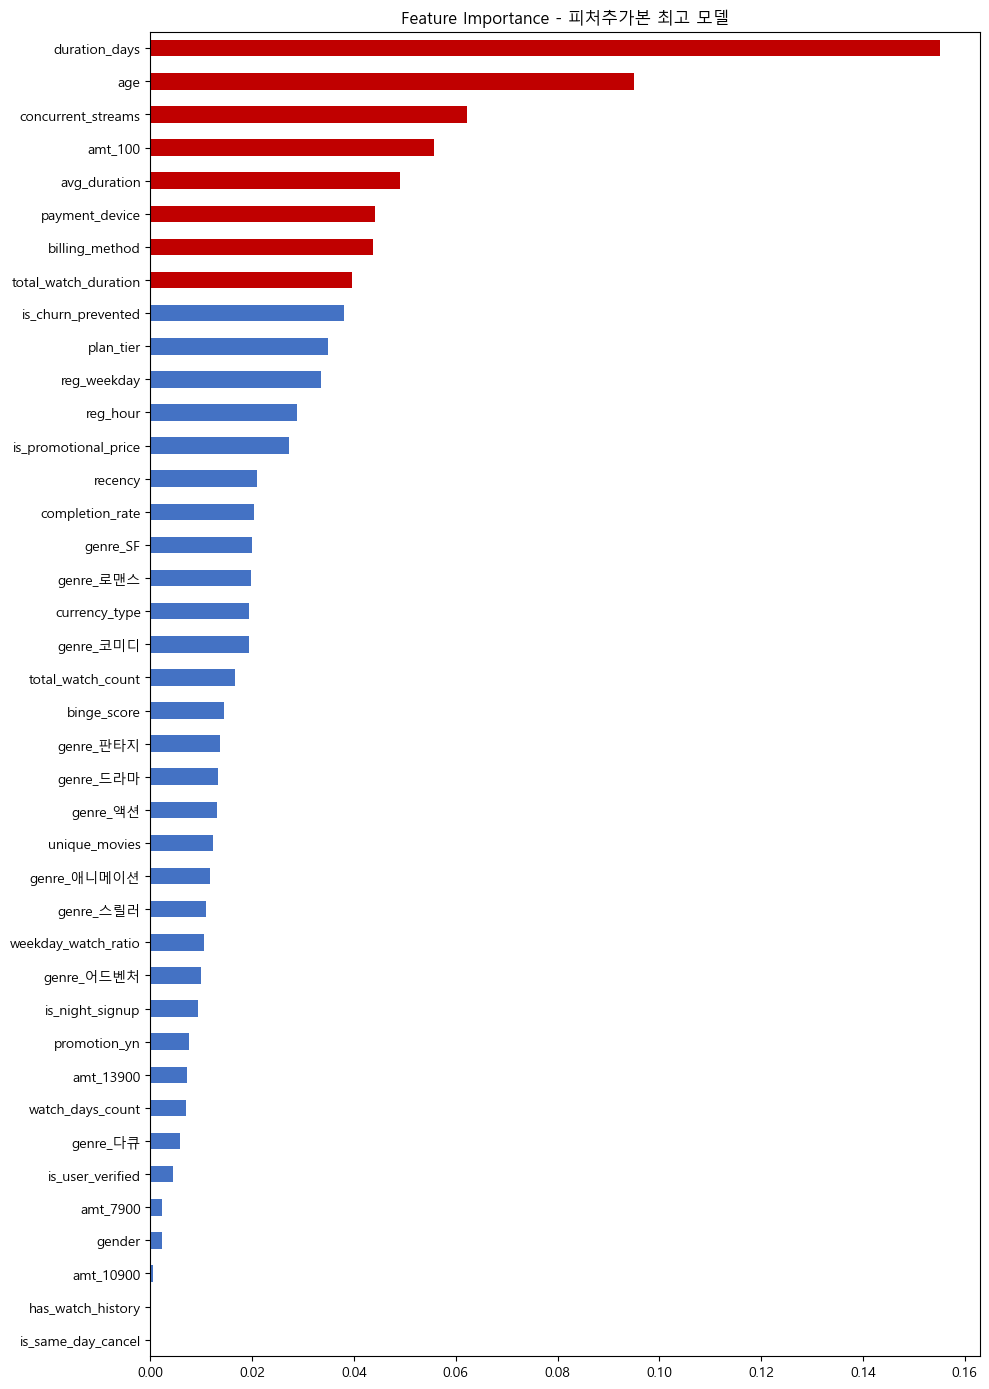

Top 15 피처:
duration_days           0.155256
age                     0.094941
concurrent_streams      0.062227
amt_100                 0.055717
avg_duration            0.049095
payment_device          0.044139
billing_method          0.043656
total_watch_duration    0.039688
is_churn_prevented      0.038011
plan_tier               0.034870
reg_weekday             0.033522
reg_hour                0.028846
is_promotional_price    0.027146
recency                 0.020961
completion_rate         0.020413
dtype: float64


In [9]:
m = best_v2["model"]
if hasattr(m, "named_steps"): m = list(m.named_steps.values())[-1]

if hasattr(m, "feature_importances_"):
    fi = pd.Series(m.feature_importances_, index=X_v2.columns).sort_values(ascending=True)
    colors = ["#c00000" if v >= fi.quantile(0.8) else "#4472C4" for v in fi.values]
    fig, ax = plt.subplots(figsize=(10, 14))
    fi.plot(kind="barh", ax=ax, color=colors)
    ax.set_title("Feature Importance - 피처추가본 최고 모델")
    plt.tight_layout(); plt.show()
    print("Top 15 피처:")
    print(fi.sort_values(ascending=False).head(15))
elif hasattr(m, "coef_"):
    fi = pd.Series(np.abs(m.coef_[0]), index=X_v2.columns).sort_values(ascending=True)
    fi.plot(kind="barh", figsize=(10, 14), title="Coefficient 절댓값")
    plt.tight_layout(); plt.show()

## 7. 5-Fold 교차검증

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for results, X, y, label in [
    (results_raw,  X_raw,  y_raw,  "원본"),
    (results_proc, X_proc, y_proc, "전처리본"),
    (results_v2,   X_v2,   y_v2,   "피처추가본"),
]:
    print(f"\n=== {label} 5-Fold CV AUC ===")
    for r in results:
        s = cross_val_score(r["model"], X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
        nm = r["name"]
        print(f"  {nm:<25}  mean={s.mean():.4f}  std={s.std():.4f}")


=== 원본 5-Fold CV AUC ===
  Logistic Regression        mean=0.6161  std=0.0034
  Random Forest              mean=0.5851  std=0.0106
  Gradient Boosting          mean=0.6533  std=0.0027
  LightGBM                   mean=0.6289  std=0.0062
  XGBoost                    mean=0.6087  std=0.0074

=== 전처리본 5-Fold CV AUC ===
  Logistic Regression        mean=0.6404  std=0.0040
  Random Forest              mean=0.6332  std=0.0018
  Gradient Boosting          mean=0.6597  std=0.0037
  LightGBM                   mean=0.6379  std=0.0070
  XGBoost                    mean=0.6101  std=0.0033

=== 피처추가본 5-Fold CV AUC ===
  Logistic Regression        mean=0.6405  std=0.0047
  Random Forest              mean=0.6379  std=0.0041
  Gradient Boosting          mean=0.6551  std=0.0055
  LightGBM                   mean=0.6370  std=0.0050
  XGBoost                    mean=0.6146  std=0.0035


## 8. Optuna 하이퍼파라미터 튜닝 (원본 vs 전처리본 vs 피처추가본 비교)

In [12]:
import sys
!{sys.executable} -m pip install optuna -q


In [13]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def make_objective_lgb(X_tr, y_tr):
    def objective(trial):
        params = {
            "n_estimators":      trial.suggest_int("n_estimators", 100, 1000),
            "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "max_depth":         trial.suggest_int("max_depth", 3, 10),
            "num_leaves":        trial.suggest_int("num_leaves", 20, 200),
            "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
            "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "reg_alpha":         trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            "reg_lambda":        trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            "random_state": 42, "verbose": -1,
        }
        model = lgb.LGBMClassifier(**params)
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        return cross_val_score(model, X_tr, y_tr, cv=cv, scoring="roc_auc", n_jobs=-1).mean()
    return objective

def make_objective_xgb(X_tr, y_tr):
    def objective(trial):
        params = {
            "n_estimators":      trial.suggest_int("n_estimators", 100, 1000),
            "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "max_depth":         trial.suggest_int("max_depth", 3, 10),
            "min_child_weight":  trial.suggest_int("min_child_weight", 1, 10),
            "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "gamma":             trial.suggest_float("gamma", 1e-8, 1.0, log=True),
            "reg_alpha":         trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            "reg_lambda":        trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            "eval_metric": "logloss", "verbosity": 0, "random_state": 42,
        }
        model = xgb.XGBClassifier(**params)
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        return cross_val_score(model, X_tr, y_tr, cv=cv, scoring="roc_auc", n_jobs=-1).mean()
    return objective

N_TRIALS = 50
datasets = [
    ("원본",       Xr_tr, yr_tr, Xr_te, yr_te),
    ("전처리본",   Xp_tr, yp_tr, Xp_te, yp_te),
    ("피처추가본", Xv_tr, yv_tr, Xv_te, yv_te),
]

optuna_results = []
for label, X_tr, y_tr, X_te, y_te in datasets:
    print(f"\n[{label}] LightGBM ({N_TRIALS} trials)...")
    study_lgb = optuna.create_study(direction="maximize")
    study_lgb.optimize(make_objective_lgb(X_tr, y_tr), n_trials=N_TRIALS, show_progress_bar=True)

    print(f"[{label}] XGBoost  ({N_TRIALS} trials)...")
    study_xgb = optuna.create_study(direction="maximize")
    study_xgb.optimize(make_objective_xgb(X_tr, y_tr), n_trials=N_TRIALS, show_progress_bar=True)

    # Test 세트 평가
    lgb_model = lgb.LGBMClassifier(**study_lgb.best_params, random_state=42, verbose=-1)
    lgb_model.fit(X_tr, y_tr)
    xgb_model = xgb.XGBClassifier(**study_xgb.best_params, random_state=42, eval_metric="logloss", verbosity=0)
    xgb_model.fit(X_tr, y_tr)

    lgb_auc = roc_auc_score(y_te, lgb_model.predict_proba(X_te)[:,1])
    lgb_acc = accuracy_score(y_te, lgb_model.predict(X_te))
    xgb_auc = roc_auc_score(y_te, xgb_model.predict_proba(X_te)[:,1])
    xgb_acc = accuracy_score(y_te, xgb_model.predict(X_te))

    optuna_results.append({"데이터셋": label,
        "LGB_AUC_CV": study_lgb.best_value, "LGB_AUC_Test": lgb_auc, "LGB_Acc": lgb_acc,
        "XGB_AUC_CV": study_xgb.best_value, "XGB_AUC_Test": xgb_auc, "XGB_Acc": xgb_acc,
        "lgb_model": lgb_model, "xgb_model": xgb_model, "label": label,
        "X_te": X_te, "y_te": y_te})
    print(f"  LGB CV={study_lgb.best_value:.4f}  Test AUC={lgb_auc:.4f}  Acc={lgb_acc:.4f}")
    print(f"  XGB CV={study_xgb.best_value:.4f}  Test AUC={xgb_auc:.4f}  Acc={xgb_acc:.4f}")

LightGBM Optuna (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


XGBoost Optuna (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


LightGBM 최적 AUC (CV): 0.6567
최적 파라미터: {'n_estimators': 102, 'learning_rate': 0.02209192836836435, 'max_depth': 6, 'num_leaves': 152, 'min_child_samples': 92, 'subsample': 0.9326770941216369, 'colsample_bytree': 0.7000927622507648, 'reg_alpha': 0.046753837842554206, 'reg_lambda': 0.4779845241073862}

XGBoost  최적 AUC (CV): 0.6584
최적 파라미터: {'n_estimators': 174, 'learning_rate': 0.01011199966844726, 'max_depth': 6, 'min_child_weight': 4, 'subsample': 0.903663229456922, 'colsample_bytree': 0.5624673058150861, 'gamma': 3.188129056833205e-05, 'reg_alpha': 5.724733350847731e-07, 'reg_lambda': 9.835924673561196}


,LGB AUC(CV),LGB AUC(Test),LGB Acc,XGB AUC(CV),XGB AUC(Test),XGB Acc
데이터셋,,,,,,
원본,0.6473,0.6681,0.6871,0.6488,0.6666,0.6885
전처리본,0.6596,0.6751,0.6937,0.6623,0.6750,0.6954
피처추가본,0.6581,0.6750,0.6909,0.6580,0.6737,0.6875


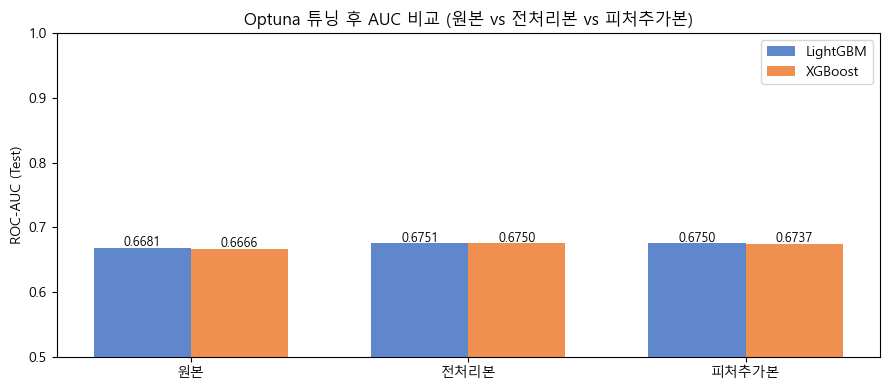

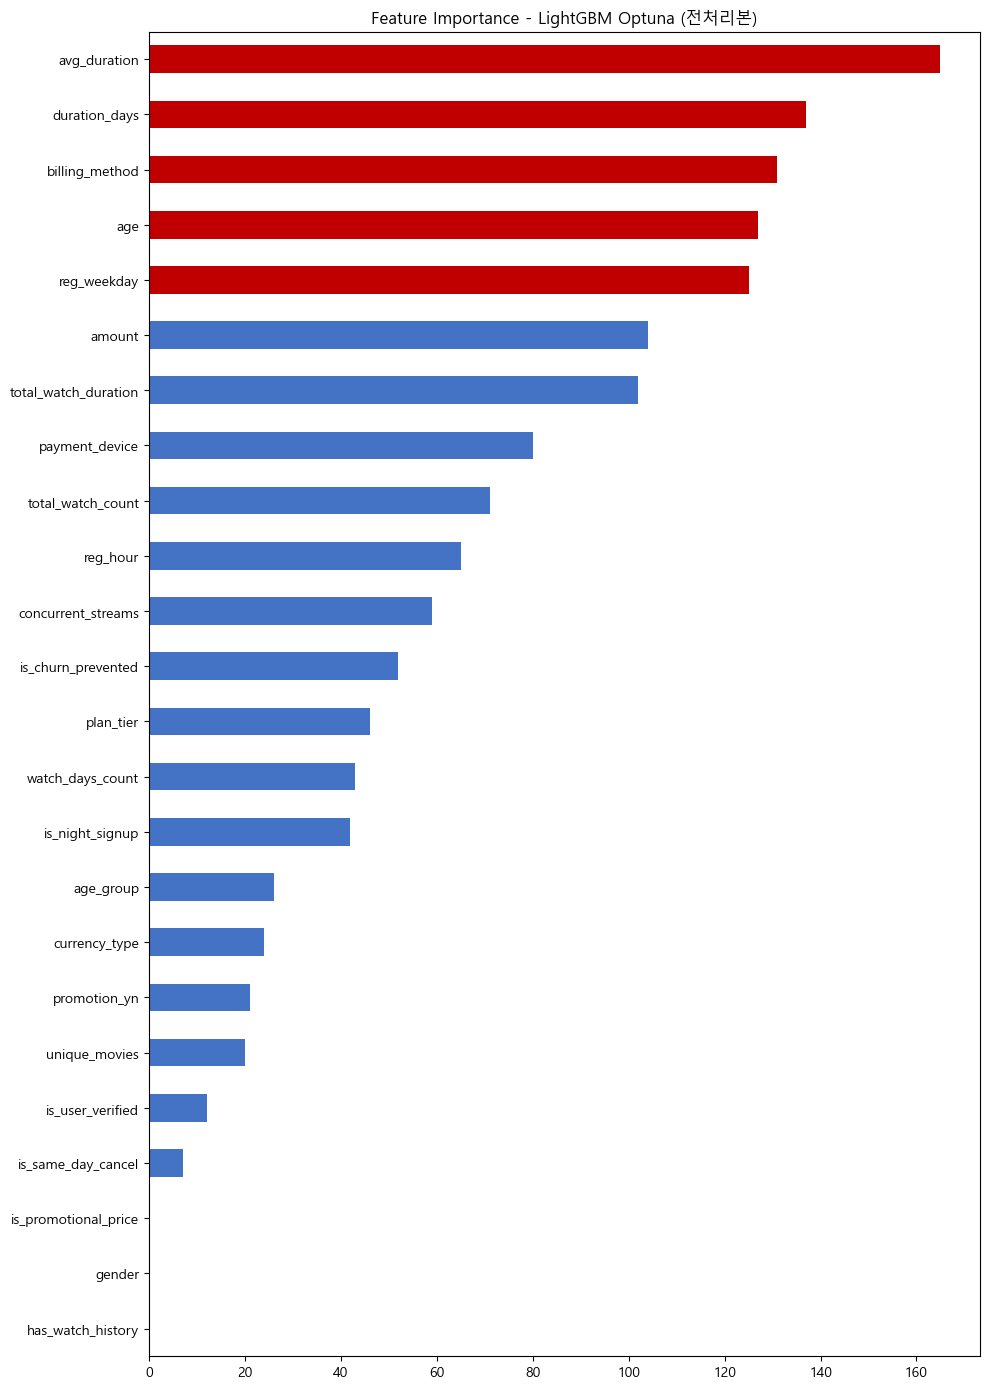

Top 10 피처:
avg_duration            165
duration_days           137
billing_method          131
age                     127
reg_weekday             125
amount                  104
total_watch_duration    102
payment_device           80
total_watch_count        71
reg_hour                 65
dtype: int32


In [32]:
# 비교표
rows = []
for r in optuna_results:
    rows.append({"데이터셋": r["데이터셋"],
        "LGB AUC(CV)": r["LGB_AUC_CV"], "LGB AUC(Test)": r["LGB_AUC_Test"], "LGB Acc": r["LGB_Acc"],
        "XGB AUC(CV)": r["XGB_AUC_CV"], "XGB AUC(Test)": r["XGB_AUC_Test"], "XGB Acc": r["XGB_Acc"]})
df_opt = pd.DataFrame(rows).set_index("데이터셋")
display(df_opt.style.highlight_max(color="#c6efce").format("{:.4f}"))

# AUC 비교 차트
labels  = [r["데이터셋"] for r in optuna_results]
lgb_auc = [r["LGB_AUC_Test"] for r in optuna_results]
xgb_auc = [r["XGB_AUC_Test"] for r in optuna_results]
x = np.arange(len(labels)); w = 0.35

fig, ax = plt.subplots(figsize=(9, 4))
b1 = ax.bar(x-w/2, lgb_auc, w, label="LightGBM", color="#4472C4", alpha=0.85)
b2 = ax.bar(x+w/2, xgb_auc, w, label="XGBoost",  color="#ED7D31", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0.5, 1.0); ax.set_ylabel("ROC-AUC (Test)")
ax.set_title("Optuna 튜닝 후 AUC 비교 (원본 vs 전처리본 vs 피처추가본)"); ax.legend()
for b,v in zip(b1,lgb_auc): ax.text(b.get_x()+b.get_width()/2, v+0.003, f"{v:.4f}", ha="center", fontsize=9)
for b,v in zip(b2,xgb_auc): ax.text(b.get_x()+b.get_width()/2, v+0.003, f"{v:.4f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

# 최고 모델 Feature Importance
best_r = max(optuna_results, key=lambda r: r["LGB_AUC_Test"])
fi = pd.Series(best_r["lgb_model"].feature_importances_, index=best_r["X_te"].columns).sort_values(ascending=True)
colors = ["#c00000" if v >= fi.quantile(0.8) else "#4472C4" for v in fi.values]
fig, ax = plt.subplots(figsize=(10, 14))
fi.plot(kind="barh", ax=ax, color=colors)
best_label = best_r["label"]
ax.set_title(f"Feature Importance - LightGBM Optuna ({best_label})")
plt.tight_layout(); plt.show()
print("Top 10 피처:")
print(fi.sort_values(ascending=False).head(10))